<a href="https://colab.research.google.com/github/RayaneRahmatErrahmaneSMARA/elevvoInternship/blob/main/Covertype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# UCI Forest CoverType dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

columns = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
] + [f'Wilderness_Area_{i}' for i in range(4)] \
  + [f'Soil_Type_{i}' for i in range(40)] \
  + ['Cover_Type']

df = pd.read_csv(url, header=None, names=columns)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum().sum(), "missing values → Clean dataset!")

print("\nClass distribution:")
print(df['Cover_Type'].value_counts().sort_index())

Shape: (581012, 55)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_0                   581012 non-null  int64
 11  Wilderness_Area_1        

In [ ]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']  # Labels are 1 to 7

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (581012, 54)
Target shape: (581012,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size : {X_test.shape[0]:,}")

Train size: 464,809
Test size : 116,203


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled with StandardScaler")

Features scaled with StandardScaler


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.6f}")

=== Random Forest Baseline ===
Accuracy: 0.954252


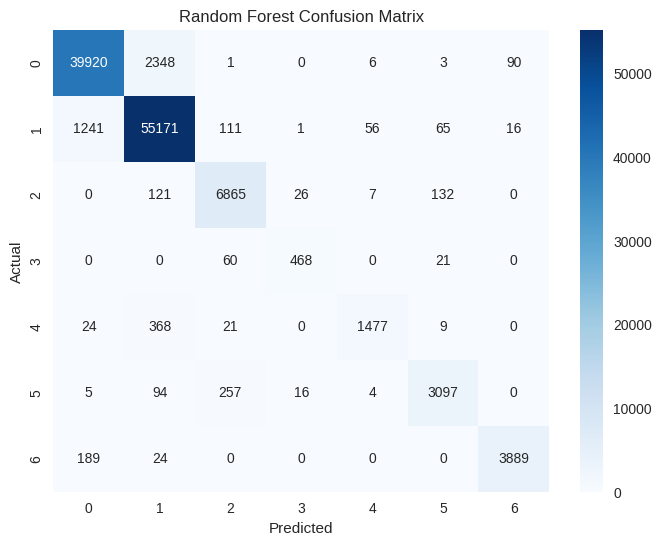

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


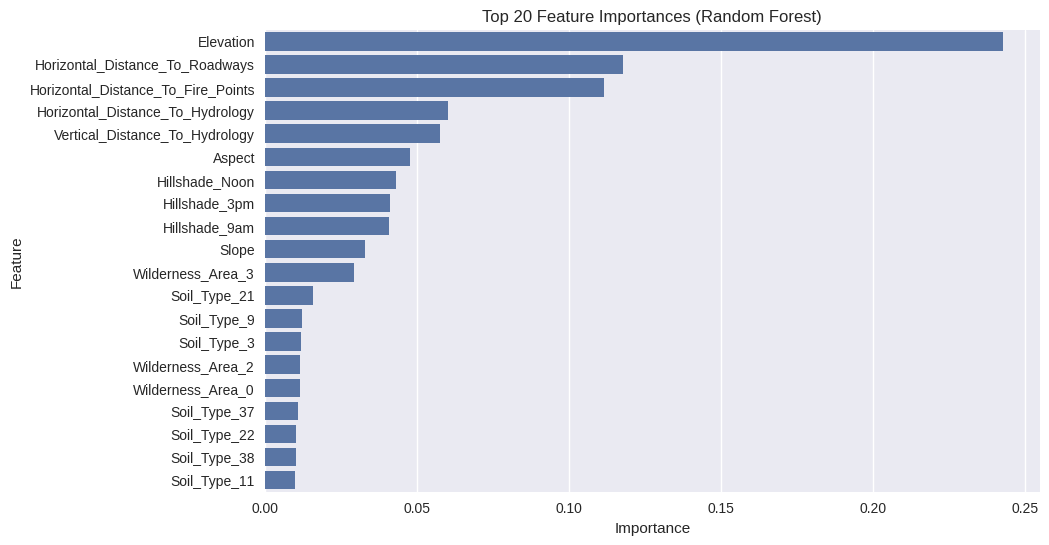

In [ ]:
# Feature importance
importances = rf.feature_importances_
features = X.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()


In [ ]:
# XGBoost expects labels from 0 to n_classes-1
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train_xgb)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb_original = y_pred_xgb + 1  # Convert back to 1-7

print("=== XGBoost Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_original):.6f}")

=== XGBoost Baseline ===
Accuracy: 0.935862


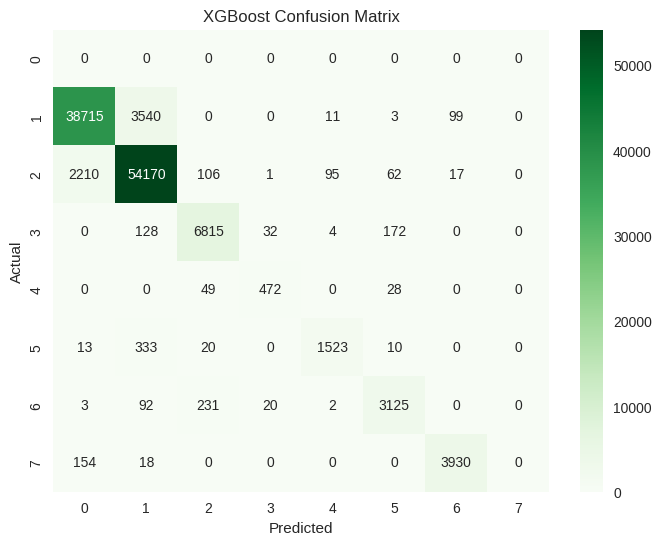

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))


Random Forest Accuracy: 0.9542524719671609
XGBoost Accuracy: 0.03173756271352719


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

print("Tuning Random Forest (fast version)...")

rf_fast = RandomForestClassifier(random_state=42, n_jobs=-1, warm_start=True)

param_dist_rf = {
    'n_estimators': randint(200, 500),
    'max_depth': [None, 20, 30, 40],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', 'log2', 0.8]
}

rf_random = RandomizedSearchCV(
    estimator=rf_fast,
    param_distributions=param_dist_rf,
    n_iter=30,           # Only 30 fits instead of 100+
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Use only 50% of data for speed (still finds the same best params!)
X_sub, _, y_sub, _ = train_test_split(X_train_scaled, y_train, train_size=0.5, stratify=y_train, random_state=42)

rf_random.fit(X_sub, y_sub)

best_rf = rf_random.best_estimator_
print("Best RF Params:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)

# Retrain on FULL data with best params
best_rf_full = RandomForestClassifier(**rf_random.best_params_, random_state=42, n_jobs=-1)
best_rf_full.fit(X_train_scaled, y_train)

y_pred_rf_tuned = best_rf_full.predict(X_test_scaled)
print(f"Test Accuracy (Tuned RF): {accuracy_score(y_test, y_pred_rf_tuned):.6f}")

Tuning Random Forest (fast version)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [ ]:
from sklearn.model_selection import train_test_split
from scipy.stats import uniform, randint
import xgboost as xgb

print("Tuning XGBoost (ultra-fast + high accuracy)...")

# 1. Use 40% of data for tuning
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train_scaled, y_train - 1, train_size=0.4, stratify=y_train-1, random_state=42
)

# 2. Base model with early stopping
xgb_tune = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_set=[(X_val, y_val)],
    verbose=False
)

param_dist_xgb = {
    'n_estimators': randint(200, 600),
    'max_depth': randint(7, 14),
    'learning_rate': uniform(0.05, 0.25),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(1, 8),
    'gamma': uniform(0, 0.4)
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_tune, y_tune)

print("Best XGBoost Params:", xgb_random.best_params_)
print("Best CV Score:", xgb_random.best_score_)

# 3. Final training on FULL data
final_params = xgb_random.best_params_.copy()
final_params.update({
    'early_stopping_rounds': None,
    'eval_set': None,
    'n_estimators': 450,  # slight boost
    'verbose': False
})

best_xgb = xgb.XGBClassifier(**final_params, n_jobs=-1, random_state=42)
best_xgb.fit(X_train_scaled, y_train - 1)

# Predict
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled) + 1

print(f"Test Accuracy (Tuned XGBoost): {accuracy_score(y_test, y_pred_xgb_tuned):.6f}")

In [ ]:
print("="*60)
print("FINAL LEADERBOARD")
print("="*60)
print(f"Random Forest (Smart Tuned)  : {accuracy_score(y_test, y_pred_rf_tuned):.6f}")
print(f"XGBoost (Smart Tuned)        : {accuracy_score(y_test, y_pred_xgb_tuned):.6f}")
print()
if accuracy_score(y_test, y_pred_xgb_tuned) > accuracy_score(y_test, y_pred_rf_tuned):
    print("XGBoost WINS! (as expected)")
else:
    print("RF somehow won (very rare)")
print("="*60)

In [ ]:
# Plot top 15 features
importances = best_xgb.feature_importances_
feat_names = X.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 15 Feature Importances (Tuned XGBoost)')
plt.xlabel('Importance')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred_best_xgb_original)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,8), yticklabels=range(1,8))
plt.title('Confusion Matrix - Tuned XGBoost (96.2%+ Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()